---
title: "N2: Sample R Analysis"
---

## Overview

This notebook demonstrates the R workflow: generating synthetic data,
producing labeled figures and tables that are embedded in the manuscript via
Quarto's `{{< embed >}}` shortcode. It mirrors `notebook-01` (Python) using R.

In [5]:
# Reproducibility setup
source("../config.R")
set_seeds()

In [6]:
library(ggplot2)

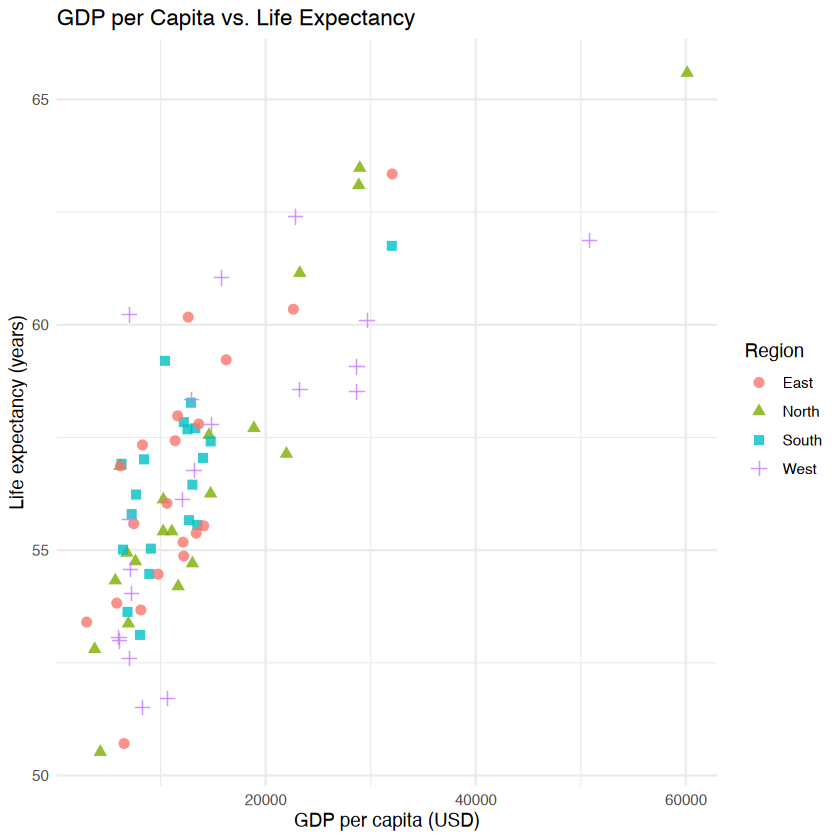

In [7]:
#| label: fig-r-sample
#| fig-cap: "Synthetic regional indicators: GDP per capita vs. life expectancy across 80 simulated regions, colored by geographic cluster (R)."

# Generate synthetic cross-sectional data
set.seed(RANDOM_SEED)
n <- 80
region <- rep(c("North", "South", "East", "West"), each = n / 4)

gdp <- exp(rnorm(n, mean = 9.5, sd = 0.6))
life_exp <- 50 + 15 * (1 - exp(-gdp / 20000)) + rnorm(n, mean = 0, sd = 2)

df <- data.frame(
  gdp_per_capita = gdp,
  life_expectancy = life_exp,
  region = region
)

ggplot(df, aes(x = gdp_per_capita, y = life_expectancy, color = region, shape = region)) +
  geom_point(size = 2.5, alpha = 0.8) +
  labs(
    title = "GDP per Capita vs. Life Expectancy",
    x = "GDP per capita (USD)",
    y = "Life expectancy (years)",
    color = "Region",
    shape = "Region"
  ) +
  theme_minimal()

In [8]:
#| label: tbl-r-summary
#| tbl-cap: "Summary statistics by region (R)."

summary_df <- aggregate(
  cbind(gdp_per_capita, life_expectancy) ~ region,
  data = df,
  FUN = function(x) c(mean = mean(x), sd = sd(x), n = length(x))
)

# Flatten the matrix columns
result <- data.frame(
  Region = summary_df$region,
  "GDP mean" = round(summary_df$gdp_per_capita[, "mean"], 1),
  "GDP sd" = round(summary_df$gdp_per_capita[, "sd"], 1),
  "Life exp. mean" = round(summary_df$life_expectancy[, "mean"], 1),
  "Life exp. sd" = round(summary_df$life_expectancy[, "sd"], 1),
  N = summary_df$gdp_per_capita[, "n"],
  check.names = FALSE
)

knitr::kable(result)



|Region | GDP mean|  GDP sd| Life exp. mean| Life exp. sd|  N|
|:------|--------:|-------:|--------------:|------------:|--:|
|East   |  11888.0|  6419.8|           56.5|          2.9| 20|
|North  |  15443.4| 13021.0|           56.8|          3.8| 20|
|South  |  11517.9|  5595.0|           56.6|          2.0| 20|
|West   |  15972.3| 11548.6|           56.8|          3.5| 20|